Training GAN...
Epoch [1/30]  Loss D: 1.0071, Loss G: 1.8844
Epoch [2/30]  Loss D: 0.8427, Loss G: 2.5659
Epoch [3/30]  Loss D: 1.2974, Loss G: 1.5820
Epoch [4/30]  Loss D: 1.2977, Loss G: 1.1350
Epoch [5/30]  Loss D: 0.5480, Loss G: 2.3579
Epoch [6/30]  Loss D: 1.1914, Loss G: 1.8547
Epoch [7/30]  Loss D: 1.3082, Loss G: 3.0923
Epoch [8/30]  Loss D: 0.8329, Loss G: 4.1681
Epoch [9/30]  Loss D: 0.7698, Loss G: 3.9659
Epoch [10/30]  Loss D: 1.8280, Loss G: 1.9269
Epoch [11/30]  Loss D: 0.8862, Loss G: 2.0897
Epoch [12/30]  Loss D: 1.4677, Loss G: 5.6507
Epoch [13/30]  Loss D: 0.4270, Loss G: 2.9006
Epoch [14/30]  Loss D: 0.6822, Loss G: 2.4721
Epoch [15/30]  Loss D: 0.3962, Loss G: 4.1883
Epoch [16/30]  Loss D: 0.6091, Loss G: 4.5824
Epoch [17/30]  Loss D: 0.3854, Loss G: 3.4075
Epoch [18/30]  Loss D: 0.3860, Loss G: 3.8483
Epoch [19/30]  Loss D: 0.3416, Loss G: 4.6416
Epoch [20/30]  Loss D: 0.3782, Loss G: 3.1932
Epoch [21/30]  Loss D: 0.6467, Loss G: 4.1255
Epoch [22/30]  Loss D: 0.40

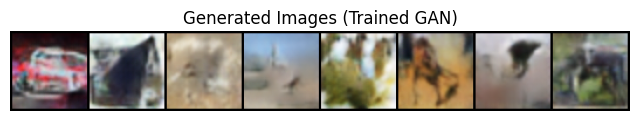

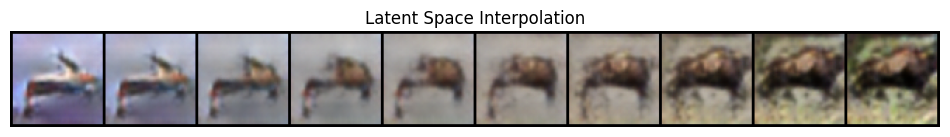

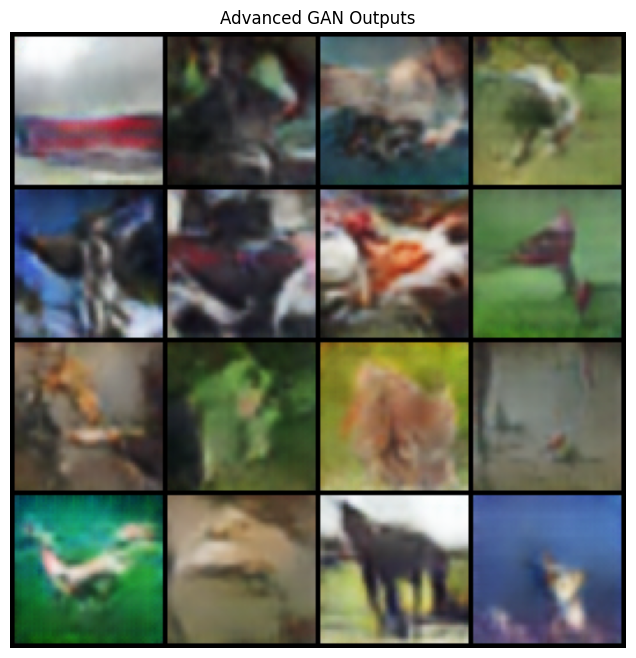

In [16]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 2. DATA PREPARATION
# =========================
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

latent_dim = 100

# =========================
# 3. GENERATOR
# =========================
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # Number of feature maps in the generator
        ngf = 64
        self.model = nn.Sequential(
            # Input: latent_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False), # Output: (ngf*8) x 4 x 4
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False), # Output: (ngf*4) x 8 x 8
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False), # Output: (ngf*2) x 16 x 16
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False), # Output: ngf x 32 x 32
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False), # Output: 3 x 64 x 64
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# =========================
# 4. DISCRIMINATOR
# =========================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Number of feature maps in the discriminator
        ndf = 64
        self.model = nn.Sequential(
            # Input: 3 x 64 x 64
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False), # Output: ndf x 32 x 32
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False), # Output: (ndf*2) x 16 x 16
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False), # Output: (ndf*4) x 8 x 8
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False), # Output: (ndf*8) x 4 x 4
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False), # Output: 1 x 1 x 1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

# =========================
# 5. INIT
# =========================
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0003, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

# =========================
# 6. TRAINING
# =========================
epochs = 30  # increase to 10+ for better results

print("Training GAN...")

for epoch in range(epochs):
    for real_images, _ in dataloader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, device=device) *0.9
        fake_labels = torch.zeros(batch_size, device=device)

        # ---- Train Discriminator ----
        # Train with real images
        discriminator.zero_grad()
        d_real = discriminator(real_images)
        loss_D_real = criterion(d_real, real_labels)
        loss_D_real.backward()

        # Train with fake images
        z = torch.randn(batch_size, latent_dim, 1, 1).to(device)
        fake_images = generator(z)
        d_fake = discriminator(fake_images.detach())
        loss_D_fake = criterion(d_fake, fake_labels)
        loss_D_fake.backward()

        loss_D = loss_D_real + loss_D_fake
        optimizer_D.step()

        # ---- Train Generator ----
        generator.zero_grad()
        output = discriminator(fake_images)
        loss_G = criterion(output, real_labels)
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

print("Training complete!")

# =========================
# 7. GENERATE IMAGES
# =========================
def generate_images(generator, num_images=8):
    generator.eval() # Set generator to evaluation mode
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, 1, 1).to(device)
        images = generator(z).cpu()

    grid = vutils.make_grid(images, normalize=True)

    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis("off")
    plt.title("Generated Images (Trained GAN)")
    plt.show()

# =========================
# 8. LATENT INTERPOLATION
# =========================
def interpolate(generator, steps=10):
    generator.eval() # Set generator to evaluation mode
    with torch.no_grad():
        z1 = torch.randn(1, latent_dim, 1, 1).to(device)
        z2 = torch.randn(1, latent_dim, 1, 1).to(device)

        images = []

        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * z1 + alpha * z2
            img = generator(z).cpu()
            images.append(img)

    grid = vutils.make_grid(torch.cat(images), normalize=True, nrow=steps)

    plt.figure(figsize=(12, 4))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis("off")
    plt.title("Latent Space Interpolation")
    plt.show()

# =========================
# 9. ADVANCED OUTPUTS
# =========================
def advanced_generation(generator):
    generator.eval() # Set generator to evaluation mode
    with torch.no_grad():
        z = torch.randn(16, latent_dim, 1, 1).to(device)
        images = generator(z).cpu()

    grid = vutils.make_grid(images, normalize=True, nrow=4)

    plt.figure(figsize=(10, 8))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis("off")
    plt.title("Advanced GAN Outputs")
    plt.show()

# =========================
# 10. RUN ALL
# =========================
generate_images(generator, 8)
interpolate(generator, 10)
advanced_generation(generator)